# Final Model SHAP Interpretation

This notebook explains what the frozen final models are actually paying attention to, using SHAP. Nothing is trained or tuned here, the models loaded in are exactly the ones frozen in the previous notebook, and everything is computed on the final test set only.


## Import libraries


In [3]:
from pathlib import Path
import gc

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


## Set paths and explanation settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
final_result_folder = project_root / "data" / "modeling" / "final_test_results"
model_folder = final_result_folder / "trained_models"
prediction_path = final_result_folder / "final_test_predictions.pkl"
predictor_list_path = final_result_folder / "final_predictor_list.csv"

preprocessor_path = model_folder / "final_ordinal_preprocessor.joblib"
xgboost_model_path = model_folder / "final_xgboost.json"
lightgbm_model_path = model_folder / "final_lightgbm.txt"
catboost_model_path = model_folder / "final_catboost.cbm"

result_folder = project_root / "data" / "modeling" / "shap_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)

required_paths = [
    dataset_path, test_ids_path, prediction_path, predictor_list_path,
    preprocessor_path, xgboost_model_path, lightgbm_model_path,
    catboost_model_path,
]
for path in required_paths:
    assert path.exists(), f"Required file missing: {path}"

RANDOM_STATE = 2026
EXPECTED_TEST_ROWS = 61503
SHAP_SAMPLE_SIZE = 10000
TOP_FEATURES = 30
print("SHAP sample size:", SHAP_SAMPLE_SIZE)
print("This notebook will not train or tune any model.")


SHAP sample size: 10000
This notebook will not train or tune any model.


## Load the frozen test data and final predictions


In [7]:
full_data = pd.read_pickle(dataset_path)
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
test_id_set = set(test_ids)
test_data = full_data.loc[
    full_data["SK_ID_CURR"].isin(test_id_set)
].copy().sort_values("SK_ID_CURR").reset_index(drop=True)
final_predictions = pd.read_pickle(prediction_path).sort_values(
    "SK_ID_CURR"
).reset_index(drop=True)
predictor_columns = pd.read_csv(predictor_list_path)["predictor"].tolist()

assert len(test_data) == EXPECTED_TEST_ROWS
assert len(final_predictions) == EXPECTED_TEST_ROWS
assert np.array_equal(
    test_data["SK_ID_CURR"].to_numpy(),
    final_predictions["SK_ID_CURR"].to_numpy()
)
assert np.array_equal(
    test_data["TARGET"].to_numpy(),
    final_predictions["TARGET"].to_numpy()
)
assert set(predictor_columns).issubset(test_data.columns)

categorical_columns = test_data[predictor_columns].select_dtypes(
    exclude="number"
).columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]
X_test = test_data[predictor_columns].copy()
for column in categorical_columns:
    X_test[column] = X_test[column].fillna("Unknown").astype(str)

print("Test rows:", len(test_data))
print("Predictors:", len(predictor_columns))
print("Numerical:", len(numerical_columns))
print("Categorical:", len(categorical_columns))


Test rows: 61503
Predictors: 330
Numerical: 318
Categorical: 12


Loads the final test set and the predictions already made by the previous notebook, and checks they line up row for row before doing anything else.


## Select a reproducible stratified explanation sample


In [10]:
all_indices = np.arange(len(test_data))
explanation_indices, _ = train_test_split(
    all_indices,
    train_size=SHAP_SAMPLE_SIZE,
    stratify=test_data["TARGET"],
    random_state=RANDOM_STATE
)
explanation_indices = np.sort(explanation_indices)

X_explain_native = X_test.iloc[explanation_indices].copy()
y_explain = test_data.loc[explanation_indices, "TARGET"].reset_index(drop=True)
explanation_ids = test_data.loc[
    explanation_indices, "SK_ID_CURR"
].reset_index(drop=True)
explanation_scores = final_predictions.loc[
    explanation_indices, "raw_equal_vote"
].reset_index(drop=True)

sample_audit = pd.DataFrame([
    {
        "dataset": "complete_test",
        "rows": len(test_data),
        "default_rate": test_data["TARGET"].mean(),
    },
    {
        "dataset": "SHAP_sample",
        "rows": len(explanation_indices),
        "default_rate": y_explain.mean(),
    },
])
sample_audit


,dataset,rows,default_rate
0,complete_test,61503,0.080728
1,SHAP_sample,10000,0.080700


SHAP is expensive to compute, so a sample of 10,000 test applicants is used instead of all 61,503, matching the same default rate as the full test set so the sample stays representative.


## Load the frozen models and preprocessing


In [13]:
preprocessor = joblib.load(preprocessor_path)

xgboost_model = xgb.Booster()
xgboost_model.load_model(xgboost_model_path)

lightgbm_model = lgb.Booster(model_file=str(lightgbm_model_path))

catboost_model = CatBoostClassifier()
catboost_model.load_model(catboost_model_path)

X_explain_encoded = preprocessor.transform(X_explain_native).astype("float32")
encoded_feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in preprocessor.get_feature_names_out()
]

assert X_explain_encoded.shape[1] == len(encoded_feature_names)
assert set(encoded_feature_names) == set(predictor_columns)
print("Frozen models loaded.")
print("Encoded explanation matrix:", X_explain_encoded.shape)


Frozen models loaded.
Encoded explanation matrix: (10000, 330)


Loads the exact frozen models and preprocessing saved by the last notebook, nothing is refit or retrained here.


## Calculate model-specific SHAP contributions


In [16]:
# XGBoost TreeSHAP
xgb_matrix = xgb.DMatrix(X_explain_encoded)
xgb_contributions_full = xgboost_model.predict(
    xgb_matrix, pred_contribs=True
)
xgb_expected_value = xgb_contributions_full[:, -1]
xgb_shap = pd.DataFrame(
    xgb_contributions_full[:, :-1],
    columns=encoded_feature_names
).reindex(columns=predictor_columns)
print("XGBoost SHAP completed:", xgb_shap.shape)

# LightGBM TreeSHAP
lgb_contributions_full = lightgbm_model.predict(
    X_explain_encoded, pred_contrib=True
)
lgb_expected_value = lgb_contributions_full[:, -1]
lgb_shap = pd.DataFrame(
    lgb_contributions_full[:, :-1],
    columns=encoded_feature_names
).reindex(columns=predictor_columns)
print("LightGBM SHAP completed:", lgb_shap.shape)

# CatBoost TreeSHAP with native categorical features
cat_pool = Pool(X_explain_native, cat_features=categorical_columns)
cat_contributions_full = catboost_model.get_feature_importance(
    cat_pool, type="ShapValues"
)
cat_expected_value = cat_contributions_full[:, -1]
cat_shap = pd.DataFrame(
    cat_contributions_full[:, :-1],
    columns=predictor_columns
)
print("CatBoost SHAP completed:", cat_shap.shape)

del xgb_matrix, cat_pool, xgb_contributions_full
del lgb_contributions_full, cat_contributions_full
gc.collect()


XGBoost SHAP completed: (10000, 330)
LightGBM SHAP completed: (10000, 330)
CatBoost SHAP completed: (10000, 330)


0

Each model type has its own native, exact way of computing SHAP values for tree models (TreeSHAP), which is faster and more precise than a generic approximation would be. CatBoost uses its own categorical handling here too, matching how it was actually trained.


## Create model-specific and consensus global importance


In [19]:
model_shap_tables = {
    "xgboost": xgb_shap,
    "lightgbm": lgb_shap,
    "catboost": cat_shap,
}

importance_rows = []
for model_name, shap_table in model_shap_tables.items():
    mean_absolute = shap_table.abs().mean()
    normalized = mean_absolute / mean_absolute.sum()
    model_table = pd.DataFrame({
        "feature": predictor_columns,
        "model": model_name,
        "mean_absolute_shap": mean_absolute.reindex(predictor_columns).to_numpy(),
        "normalized_importance": normalized.reindex(predictor_columns).to_numpy(),
    })
    importance_rows.append(model_table)

model_importance = pd.concat(importance_rows, ignore_index=True)
consensus_importance = model_importance.groupby("feature", as_index=False).agg(
    consensus_importance=("normalized_importance", "mean"),
    minimum_model_importance=("normalized_importance", "min"),
    maximum_model_importance=("normalized_importance", "max"),
)

rank_tables = []
for model_name in model_shap_tables:
    rank_table = model_importance.loc[
        model_importance["model"].eq(model_name),
        ["feature", "normalized_importance"]
    ].copy()
    rank_table[model_name + "_rank"] = rank_table[
        "normalized_importance"
    ].rank(ascending=False, method="min")
    rank_tables.append(rank_table.drop(columns="normalized_importance"))
for rank_table in rank_tables:
    consensus_importance = consensus_importance.merge(
        rank_table, on="feature", how="left", validate="one_to_one"
    )

consensus_importance["mean_rank"] = consensus_importance[
    ["xgboost_rank", "lightgbm_rank", "catboost_rank"]
].mean(axis=1)
consensus_importance = consensus_importance.sort_values(
    ["consensus_importance", "mean_rank"], ascending=[False, True]
).reset_index(drop=True)
consensus_importance.head(TOP_FEATURES).round(6)


,feature,consensus_importance,minimum_model_importance,maximum_model_importance,xgboost_rank,lightgbm_rank,catboost_rank,mean_rank
0,EXT_SOURCE_MEAN,0.082868,0.047680,0.102737,1.0,1.0,2.0,1.333333
1,APP_EXT_MEAN_SQUARED,0.027795,0.012841,0.049653,12.0,4.0,1.0,5.666667
2,APP_CREDIT_ANNUITY_RATIO,0.026420,0.025950,0.027331,2.0,2.0,3.0,2.333333
3,BUREAU_DEBT_CREDIT_RATIO_MAX,0.023988,0.023334,0.024958,3.0,3.0,5.0,3.666667
4,AMT_ANNUITY,0.021296,0.018910,0.025820,4.0,6.0,4.0,4.666667
5,NAME_EDUCATION_TYPE,0.019695,0.017924,0.022370,6.0,7.0,7.0,6.666667
6,APP_CREDIT_GOODS_DIFFERENCE,0.019587,0.018574,0.020466,5.0,5.0,8.0,6.000000
7,POS_LATEST_FUTURE_INSTALLMENTS,0.015696,0.014294,0.016679,8.0,8.0,14.0,10.000000
8,POS_FUTURE_INSTALLMENTS_MEAN,0.015478,0.013898,0.016886,9.0,11.0,9.0,9.666667
9,INST_PAID_AMOUNT_TOTAL,0.014357,0.012576,0.017034,7.0,12.0,18.0,12.333333


Each model's SHAP values get scaled to add up to 1 (so they're comparable to each other), then averaged across the three models to get one consensus importance ranking. EXT_SOURCE_MEAN comes out clearly first.


## Plot global importance


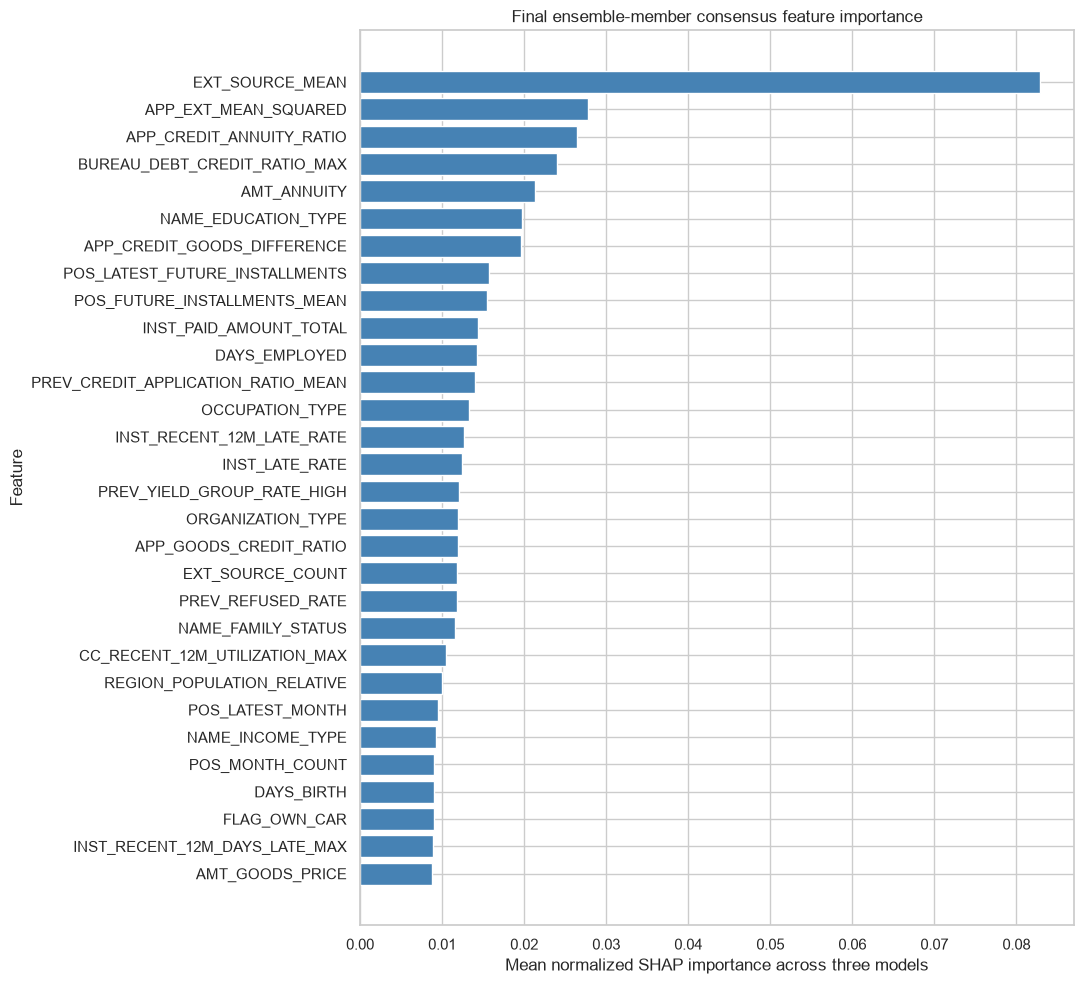

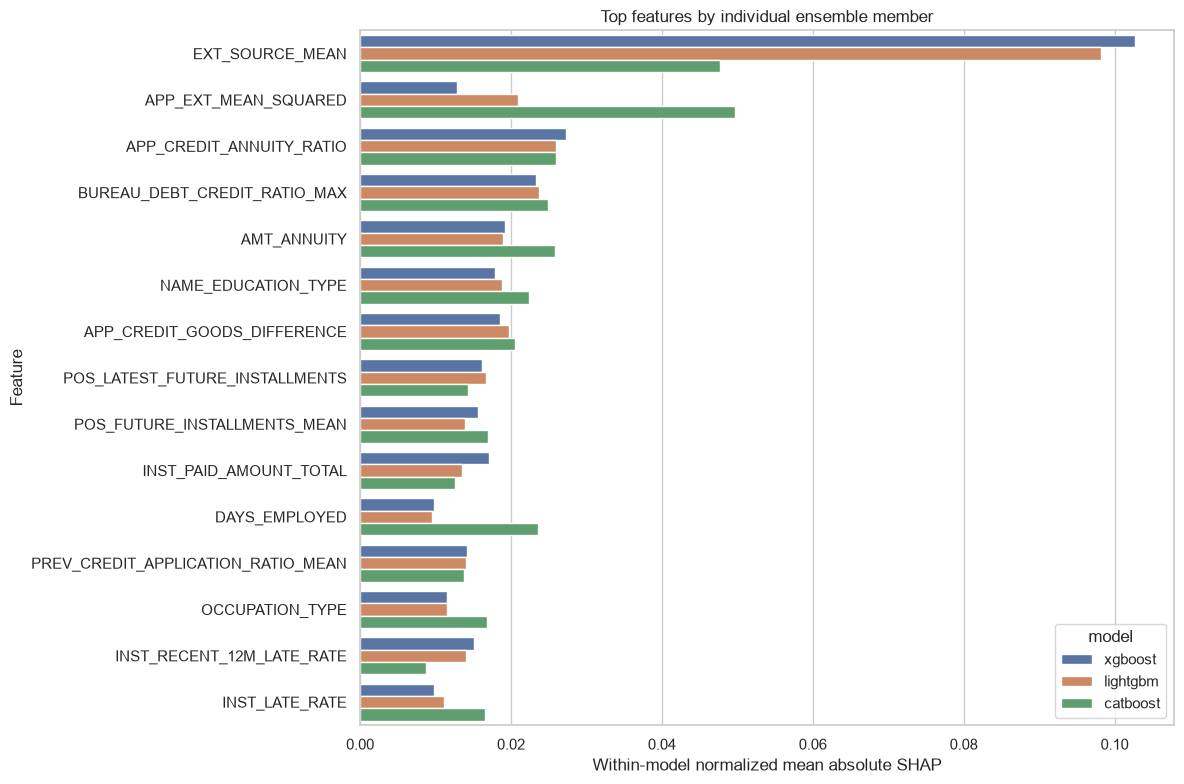

In [22]:
top_consensus = consensus_importance.head(TOP_FEATURES).sort_values(
    "consensus_importance", ascending=True
)
plt.figure(figsize=(11, 10))
plt.barh(
    top_consensus["feature"],
    top_consensus["consensus_importance"],
    color="steelblue"
)
plt.xlabel("Mean normalized SHAP importance across three models")
plt.ylabel("Feature")
plt.title("Final ensemble-member consensus feature importance")
plt.tight_layout()
plt.savefig(figure_folder / "final_shap_consensus_importance.png", dpi=180, bbox_inches="tight")
plt.show()

top_15_features = consensus_importance.head(15)["feature"].tolist()
model_plot_table = model_importance.loc[
    model_importance["feature"].isin(top_15_features)
].copy()
plt.figure(figsize=(12, 8))
sns.barplot(
    data=model_plot_table, y="feature", x="normalized_importance",
    hue="model", order=top_15_features
)
plt.title("Top features by individual ensemble member")
plt.xlabel("Within-model normalized mean absolute SHAP")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figure_folder / "final_shap_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


The consensus chart combines all three models into one ranking. The second chart breaks the top 15 features down by individual model, useful for checking whether the three models actually agree on what matters, or if one of them is relying on something different.


## Examine feature direction for important numerical predictors


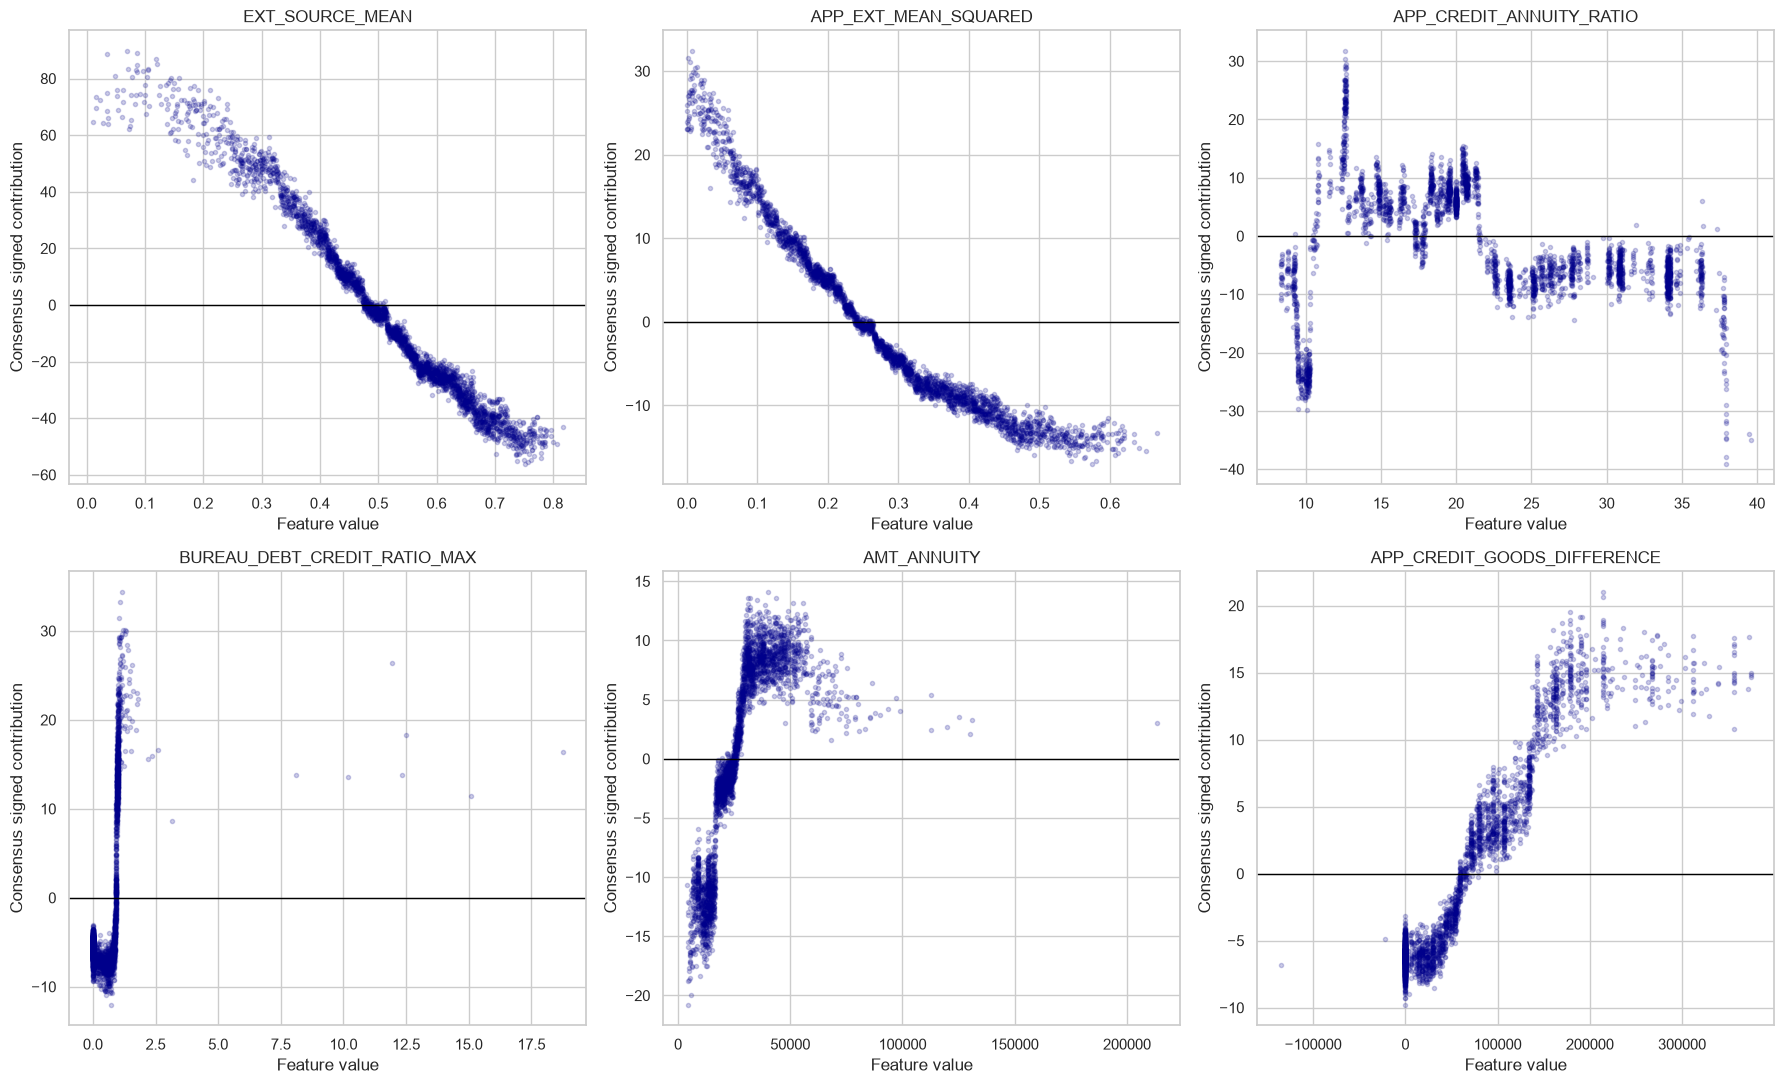

In [25]:
model_scale = {
    model_name: shap_table.abs().to_numpy().mean()
    for model_name, shap_table in model_shap_tables.items()
}
consensus_signed_shap = (
    xgb_shap / model_scale["xgboost"]
    + lgb_shap / model_scale["lightgbm"]
    + cat_shap / model_scale["catboost"]
) / 3

top_numerical_features = [
    feature for feature in consensus_importance["feature"]
    if feature in numerical_columns
][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
plot_indices = np.linspace(
    0, len(X_explain_native) - 1, min(3000, len(X_explain_native)),
    dtype=int
)
for axis, feature in zip(axes.flat, top_numerical_features):
    axis.scatter(
        X_explain_native.iloc[plot_indices][feature],
        consensus_signed_shap.iloc[plot_indices][feature],
        alpha=0.20, s=9, color="darkblue"
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(feature)
    axis.set_xlabel("Feature value")
    axis.set_ylabel("Consensus signed contribution")
plt.tight_layout()
plt.savefig(figure_folder / "final_shap_dependence_top_numeric.png", dpi=170, bbox_inches="tight")
plt.show()


Since the three models' SHAP values aren't on the same scale, each one is divided by its own average magnitude before averaging them together. This stops whichever model happens to produce larger raw SHAP numbers from dominating the combined picture.


## Create representative applicant-level explanations


In [28]:
target_quantiles = {
    "low_risk_example": 0.10,
    "typical_risk_example": 0.50,
    "high_risk_example": 0.90,
}
local_rows = []
representative_rows = []

for example_name, quantile in target_quantiles.items():
    desired_risk_score = explanation_scores.quantile(quantile)
    sample_position = (
        explanation_scores - desired_risk_score
    ).abs().idxmin()
    applicant_id = int(explanation_ids.iloc[sample_position])
    actual_target = int(y_explain.iloc[sample_position])
    predicted_risk_score = float(explanation_scores.iloc[sample_position])
    representative_rows.append({
        "example": example_name,
        "SK_ID_CURR": applicant_id,
        "TARGET": actual_target,
        "ensemble_risk_score": predicted_risk_score,
    })

    signed_row = consensus_signed_shap.iloc[sample_position]
    important_features = signed_row.abs().nlargest(12).index
    for feature in important_features:
        local_rows.append({
            "example": example_name,
            "SK_ID_CURR": applicant_id,
            "TARGET": actual_target,
            "ensemble_risk_score": predicted_risk_score,
            "feature": feature,
            "feature_value": X_explain_native.iloc[sample_position][feature],
            "consensus_signed_contribution": signed_row[feature],
            "direction": (
                "higher predicted risk" if signed_row[feature] > 0
                else "lower predicted risk"
            ),
        })

representative_applicants = pd.DataFrame(representative_rows)
local_explanations = pd.DataFrame(local_rows)
display(representative_applicants.round(5))
display(local_explanations.head(36))


,example,SK_ID_CURR,TARGET,ensemble_risk_score
0,low_risk_example,182943,0,0.01320
1,typical_risk_example,230490,0,0.04539
2,high_risk_example,176672,0,0.18920


,example,SK_ID_CURR,TARGET,ensemble_risk_score,feature,feature_value,consensus_signed_contribution,direction
0,low_risk_example,182943,0,0.013197,EXT_SOURCE_MEAN,0.625712,-24.433183,lower predicted risk
1,low_risk_example,182943,0,0.013197,POS_FUTURE_INSTALLMENTS_MEAN,18.113636,14.915565,higher predicted risk
2,low_risk_example,182943,0,0.013197,POS_LATEST_FUTURE_INSTALLMENTS,7.5,9.410645,higher predicted risk
3,low_risk_example,182943,0,0.013197,APP_EXT_MEAN_SQUARED,0.391516,-8.602602,lower predicted risk
4,low_risk_example,182943,0,0.013197,INST_OVERPAID_COUNT,6.0,-8.590871,lower predicted risk
5,low_risk_example,182943,0,0.013197,BUREAU_DEBT_CREDIT_RATIO_MAX,0.568899,-7.905532,lower predicted risk
6,low_risk_example,182943,0,0.013197,POS_TOTAL_INSTALLMENTS_MAX,48.0,7.491834,higher predicted risk
7,low_risk_example,182943,0,0.013197,INST_PAID_AMOUNT_TOTAL,1184868.0,-6.345385,lower predicted risk
8,low_risk_example,182943,0,0.013197,BUREAU_DAYS_CREDIT_MIN,-2902.0,-5.996714,lower predicted risk
9,low_risk_example,182943,0,0.013197,AMT_ANNUITY,33363.0,5.750670,higher predicted risk


Picks one applicant near the low end, middle, and high end of the risk-score range, and pulls out their top 12 contributing features. This gives a concrete example of how the model reasons about a specific person, rather than only looking at averages across everyone.


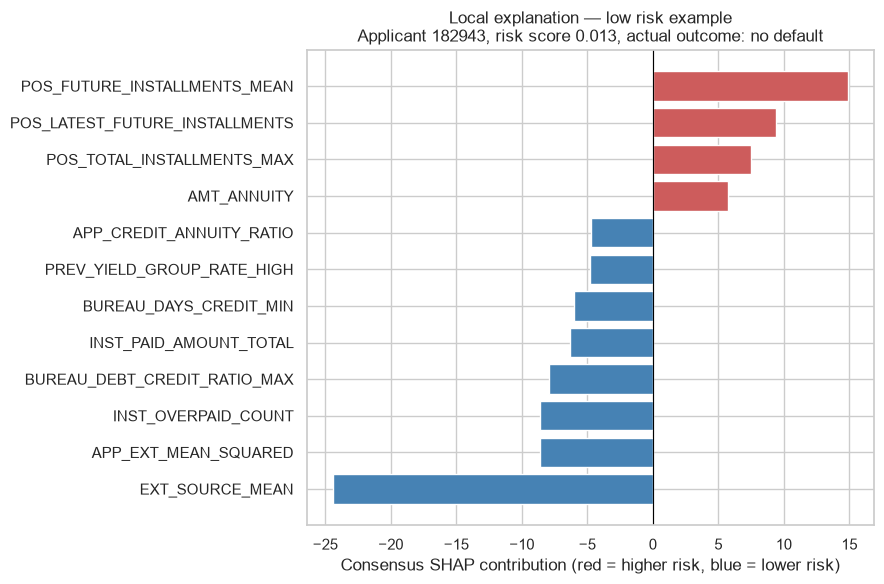

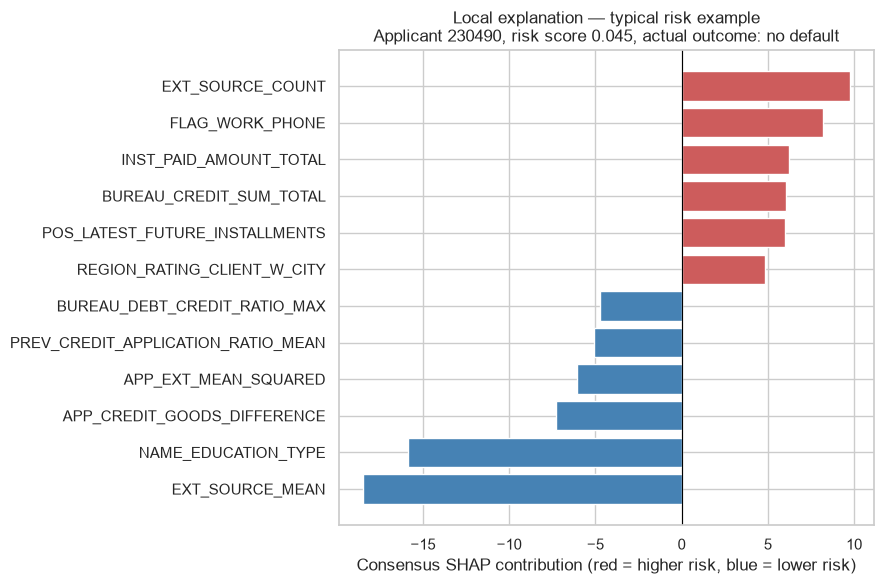

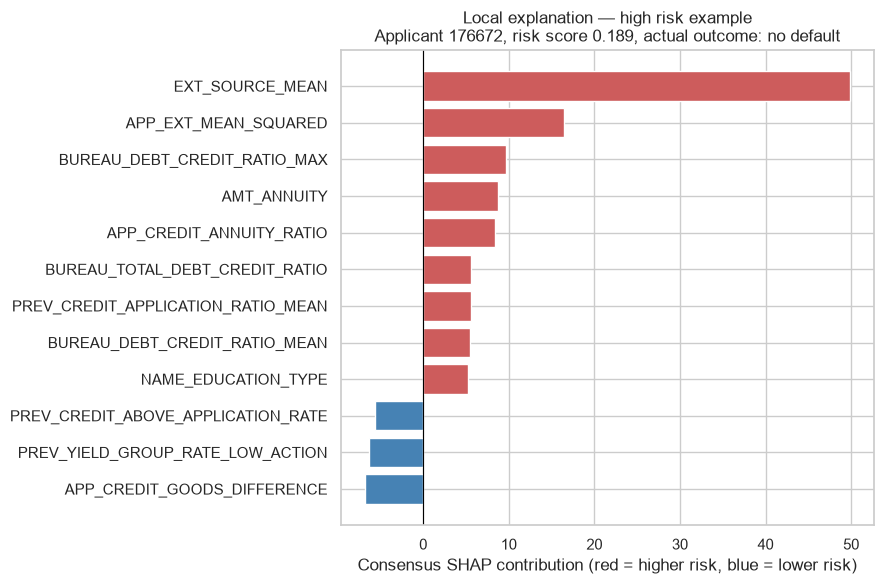

In [30]:
for example_name in target_quantiles.keys():
    example_data = local_explanations[local_explanations["example"] == example_name].copy()
    example_data = example_data.sort_values("consensus_signed_contribution")
    applicant_id = example_data["SK_ID_CURR"].iloc[0]
    risk_score = example_data["ensemble_risk_score"].iloc[0]
    actual_target = example_data["TARGET"].iloc[0]

    bar_colors = ["indianred" if v > 0 else "steelblue" for v in example_data["consensus_signed_contribution"]]

    plt.figure(figsize=(9, 6))
    plt.barh(example_data["feature"], example_data["consensus_signed_contribution"], color=bar_colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Consensus SHAP contribution (red = higher risk, blue = lower risk)")
    plt.title(
        f"Local explanation — {example_name.replace('_', ' ')}\n"
        f"Applicant {applicant_id}, risk score {risk_score:.3f}, "
        f"actual outcome: {'default' if actual_target == 1 else 'no default'}"
    )
    plt.tight_layout()
    plt.savefig(figure_folder / f"local_explanation_{example_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

## Audit and save explanation outputs


In [32]:
validation_checks = pd.DataFrame([
    {"check": "Complete final test retained", "passed": len(test_data) == EXPECTED_TEST_ROWS},
    {"check": "Prediction rows aligned by applicant ID", "passed": np.array_equal(test_data["SK_ID_CURR"].to_numpy(), final_predictions["SK_ID_CURR"].to_numpy())},
    {"check": "Stratified SHAP sample size correct", "passed": len(explanation_indices) == SHAP_SAMPLE_SIZE},
    {"check": "SHAP sample default rate representative", "passed": abs(y_explain.mean() - test_data["TARGET"].mean()) < 0.001},
    {"check": "All frozen predictors explained", "passed": set(encoded_feature_names) == set(predictor_columns)},
    {"check": "XGBoost SHAP dimensions valid", "passed": xgb_shap.shape == (SHAP_SAMPLE_SIZE, len(predictor_columns))},
    {"check": "LightGBM SHAP dimensions valid", "passed": lgb_shap.shape == (SHAP_SAMPLE_SIZE, len(predictor_columns))},
    {"check": "CatBoost SHAP dimensions valid", "passed": cat_shap.shape == (SHAP_SAMPLE_SIZE, len(predictor_columns))},
    {"check": "All SHAP values finite", "passed": all(np.isfinite(table.to_numpy()).all() for table in model_shap_tables.values())},
    {"check": "Consensus importance sums to one", "passed": np.isclose(consensus_importance["consensus_importance"].sum(), 1.0)},
    {"check": "Three representative explanations created", "passed": representative_applicants["example"].nunique() == 3},
    {"check": "No model training or tuning performed", "passed": True},
])

display(validation_checks)
assert validation_checks["passed"].all(), "At least one SHAP interpretation check failed."

sample_reference = pd.DataFrame({
    "sample_position": np.arange(SHAP_SAMPLE_SIZE),
    "SK_ID_CURR": explanation_ids,
    "TARGET": y_explain,
    "raw_equal_vote": explanation_scores,
})
sample_reference.to_csv(result_folder / "shap_sample_reference.csv", index=False)
sample_audit.to_csv(result_folder / "shap_sample_audit.csv", index=False)
model_importance.to_csv(result_folder / "model_specific_shap_importance.csv", index=False)
consensus_importance.to_csv(result_folder / "consensus_shap_importance.csv", index=False)
representative_applicants.to_csv(result_folder / "representative_applicants.csv", index=False)
local_explanations.to_csv(result_folder / "representative_local_explanations.csv", index=False)
validation_checks.to_csv(audit_folder / "final_shap_interpretation_validation.csv", index=False)

# Save SHAP matrices in compressed form for reproducibility and later analysis.
np.savez_compressed(
    result_folder / "model_shap_values_10000_rows.npz",
    xgboost=xgb_shap.to_numpy(dtype="float32"),
    lightgbm=lgb_shap.to_numpy(dtype="float32"),
    catboost=cat_shap.to_numpy(dtype="float32"),
    feature_names=np.asarray(predictor_columns),
    applicant_ids=explanation_ids.to_numpy(),
)

print("SHAP outputs saved in:", result_folder)
print("Final test predictions and metrics were not changed.")


,check,passed
0,Complete final test retained,True
1,Prediction rows aligned by applicant ID,True
2,Stratified SHAP sample size correct,True
3,SHAP sample default rate representative,True
4,All frozen predictors explained,True
5,XGBoost SHAP dimensions valid,True
6,LightGBM SHAP dimensions valid,True
7,CatBoost SHAP dimensions valid,True
8,All SHAP values finite,True
9,Consensus importance sums to one,True


SHAP outputs saved in: /Users/taranveersingh/A-MRP/data/modeling/shap_results
Final test predictions and metrics were not changed.


All checks passed. Nothing about the final predictions or metrics changed by running this notebook, it's explanation only.


## Interpretation guidance

EXT_SOURCE_MEAN dominates the ranking by a wide margin, followed by affordability and debt features (APP_CREDIT_ANNUITY_RATIO, BUREAU_DEBT_CREDIT_RATIO_MAX) and previous payment behaviour. This matches how a human loan officer would reason about risk: external credit scores first, then whether the loan is affordable, then debt load and repayment history.

One thing worth being careful about: SHAP shows what the model used to make its prediction, not what actually causes default. A feature can be genuinely useful for prediction without being a cause, for example, education level shows up as important, but that almost certainly reflects its correlation with income and stability rather than education itself causing default.
